# Regional Sales Analysis
### Exploratory Data Analysis using Python

# Project Overview

This project performs an exploratory analysis of a regional sales dataset to understand revenue distribution, customer behavior, and profitability patterns across different US states and sales channels.
Using Python-based data analysis tools, the project investigates key factors influencing sales performance and identifies high-performing regions, customers, and pricing structures. The analysis aims to uncover actionable insights that can support strategic sales and marketing decisions.

# Problem Statement

Organizations operating across multiple regions often face challenges in identifying which markets, customers, and products contribute most to overall revenue and profitability.

The goal of this project is to analyze regional sales data to answer the following key questions:

- Which regions and states generate the highest revenue?
- Which customers contribute the most to total sales?
- How do profit margins vary across pricing levels and sales channels?
- What patterns exist in order values and sales distribution?
- Are there strong relationships between quantity, price, revenue, and profit?

# Dataset Description

The dataset contains transactional sales records including customer details, product information, pricing, and geographic location.

Key fields include:

- Order Number – Unique identifier for each order
- Customer Name – Name of the purchasing customer
- Product Name – Product purchased
- Quantity – Number of units sold
- Unit Price – Price per unit
- Revenue – Total revenue generated from the order
- Cost – Total cost associated with the order
- Profit – Net profit from the transaction
- Sales Channel – Channel through which the sale occurred
- US Region – Geographic region of the sale
- State – US state where the transaction occurred

These attributes allow analysis of sales performance, profitability, and regional demand patterns.

# Objectives of the Analysis

The primary objectives of this project are:

* Analyze regional and state-level sales performance.
* Identify top revenue-generating customers and markets.
* Evaluate profit margin trends across pricing levels.
* Examine order value distribution and purchasing patterns.
* Explore correlations between key financial variables.
* Visualize insights using Python-based data visualization tools.

# Tools and Technologies Used

The analysis is performed using the following tools and libraries:

- Python
- Pandas (data manipulation)
- NumPy (numerical computations)
- Matplotlib (data visualization)
- Seaborn (statistical visualization)
- Plotly (interactive visualizations)

The final insights are also visualized through a Power BI dashboard for interactive exploration of regional sales performance.

# Analysis Workflow

The project follows a structured data analysis workflow:

1. Data loading and inspection
2. Data cleaning and feature engineering
3. Exploratory data analysis (EDA)
4. Customer and revenue analysis
5. Regional and state-level sales analysis
6. Profitability and pricing analysis
7. Correlation analysis between financial variables
8. Visualization of key insights

# Data Import

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
sheets = pd.read_excel('/content/Regional Sales Dataset.xlsx', sheet_name = None)

In [ ]:
# Assign dataframes to each sheet

df_sales = sheets['Sales Orders']
df_customers = sheets['Customers']
df_products = sheets['Products']
df_regions = sheets['Regions']
df_state_reg = sheets['State Regions']
df_budgets = sheets['2017 Budgets']

# Data Exploration

In [ ]:
df_sales.shape

(64104, 12)

In [ ]:
print("df_sales.shape:" , (df_sales.shape))
print("df_customers.shape:" , (df_customers.shape))
print("df_products.shape:" , (df_products.shape))
print("df_regions.shape:" , (df_regions.shape))
print("df_state_reg.shape:" , (df_state_reg.shape))
print("df_budgets.shape:" , (df_budgets.shape))


df_sales.shape: (64104, 12)
df_customers.shape: (175, 2)
df_products.shape: (30, 2)
df_regions.shape: (994, 15)
df_state_reg.shape: (49, 3)
df_budgets.shape: (30, 2)


In [ ]:
df_customers.head()

,Customer Index,Customer Names
0,1,Geiss Company
1,2,Jaxbean Group
2,3,Ascend Ltd
3,4,Eire Corp
4,5,Blogtags Ltd


In [ ]:
df_products.head()

,Index,Product Name
0,1,Product 1
1,2,Product 2
2,3,Product 3
3,4,Product 4
4,5,Product 5


In [ ]:
df_regions.head()

,id,name,county,state_code,state,type,latitude,longitude,area_code,population,households,median_income,land_area,water_area,time_zone
0,1,Auburn,Lee County,AL,Alabama,City,32.60986,-85.48078,334,62059,21767,38342,152375113,2646161,America/Chicago
1,2,Birmingham,Shelby County/Jefferson County,AL,Alabama,City,33.52744,-86.79905,205,212461,89972,31061,378353942,6591013,America/Chicago
2,3,Decatur,Limestone County/Morgan County,AL,Alabama,City,34.57332,-86.99214,256,55437,22294,41496,141006257,17594716,America/Chicago
3,4,Dothan,Dale County/Houston County/Henry County,AL,Alabama,City,31.23370,-85.40682,334,68567,25913,42426,232166237,835468,America/Chicago
4,5,Hoover,Shelby County/Jefferson County,AL,Alabama,City,33.37695,-86.80558,205,84848,32789,77146,122016784,2553332,America/Chicago


In [ ]:
df_state_reg.head()

,Column1,Column2,Column3
0,State Code,State,Region
1,AL,Alabama,South
2,AR,Arkansas,South
3,AZ,Arizona,West
4,CA,California,West


In [ ]:
df_budgets.head()

,Product Name,2017 Budgets
0,Product 1,3016489.209
1,Product 2,3050087.565
2,Product 3,2642352.432
3,Product 4,2885560.824
4,Product 5,3925424.542


In [ ]:
# 1. Manually set the correct headers
df_state_reg.columns = ["State Code", "State", "Region"]

# 2. Drop any duplicate header rows that appear in the data
df_state_reg = df_state_reg[df_state_reg["State Code"] != "State Code"]

# 3. Reset index
df_state_reg = df_state_reg.reset_index(drop=True)

# 4. Preview
df_state_reg.head(5)

,State Code,State,Region
0,AL,Alabama,South
1,AR,Arkansas,South
2,AZ,Arizona,West
3,CA,California,West
4,CO,Colorado,West


In [ ]:
df_sales.isnull().sum()

,0
OrderNumber,0
OrderDate,0
Customer Name Index,0
Channel,0
Currency Code,0
Warehouse Code,0
Delivery Region Index,0
Product Description Index,0
Order Quantity,0
Unit Price,0


In [ ]:
df_products.isnull().sum()

,0
Index,0
Product Name,0


In [ ]:
df_regions.isnull().sum()

,0
id,0
name,0
county,0
state_code,0
state,0
type,0
latitude,0
longitude,0
area_code,0
population,0


In [ ]:
df_budgets.isnull().sum()

,0
Product Name,0
2017 Budgets,0


Date cleaning **bold text**

In [ ]:
 # Merge with customers

 df = df_sales.merge(
     df_customers,
     how='left',
     left_on='Customer Name Index',
     right_on='Customer Index'
 )

In [ ]:
df.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost,Customer Index,Customer Names
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343,126,Rhynoodle Ltd
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918,96,Thoughtmix Ltd
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740,8,Amerisourc Corp
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852,42,Colgate-Pa Group
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270,73,Deseret Group


In [ ]:
# Merge with Products
df = df.merge(
    df_products,
    how='left',
    left_on='Product Description Index',
    right_on='Index'
)


In [ ]:
df.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost,Customer Index,Customer Names,Index,Product Name
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343,126,Rhynoodle Ltd,27,Product 27
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918,96,Thoughtmix Ltd,20,Product 20
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740,8,Amerisourc Corp,26,Product 26
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852,42,Colgate-Pa Group,7,Product 7
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270,73,Deseret Group,8,Product 8


In [ ]:
# Merge with Region
df = df.merge(
    df_regions,
    how='left',
    left_on='Delivery Region Index',
    right_on='id'
)


In [ ]:
df.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,type,latitude,longitude,area_code,population,households,median_income,land_area,water_area,time_zone
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,City,32.08354,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,City,39.61366,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,City,37.66243,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,City,39.16533,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,Town,41.77524,-72.52443,959,58007,24141,63158,70972793,720300,America/New York


In [ ]:
# Merge with state regions
df = df.merge(
    df_state_reg[["State Code", "Region"]],
    how="left",
    left_on="state_code",   # column in your main df
    right_on="State Code"   # exact column name in df_state_reg
)

In [ ]:
df.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,longitude,area_code,population,households,median_income,land_area,water_area,time_zone,State Code,Region
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York,GA,South
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,IN,Midwest
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles,CA,West
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,IN,Midwest
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,-72.52443,959,58007,24141,63158,70972793,720300,America/New York,CT,Northeast


In [ ]:
df.to_csv('file.csv')

In [ ]:
#merge with budget 2017
df = df.merge(
    df_budgets,
    how='left',
    on='Product Name'
)

In [ ]:
#Customer Index
#index
#id
#State Code

#Clean up redundant columns
cols_to_drop = ['Customer Index', 'Index', 'id', 'State Code']
df = df.drop(columns= cols_to_drop,errors = 'ignore')

df.head(5)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,longitude,area_code,population,households,median_income,land_area,water_area,time_zone,Region,2017 Budgets
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York,South,964940.231
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,Midwest,2067108.120
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles,West,5685138.270
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,Midwest,889737.555
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,-72.52443,959,58007,24141,63158,70972793,720300,America/New York,Northeast,1085037.329


In [ ]:
# convert all comns to lower case for consistency and easier access

df.columns = df.columns.str.lower()

df.columns.values

array(['ordernumber', 'orderdate', 'customer name index', 'channel',
       'currency code', 'warehouse code', 'delivery region index',
       'product description index', 'order quantity', 'unit price',
       'line total', 'total unit cost', 'customer names', 'product name',
       'name', 'county', 'state_code', 'state', 'type', 'latitude',
       'longitude', 'area_code', 'population', 'households',
       'median_income', 'land_area', 'water_area', 'time_zone', 'region',
       '2017 budgets'], dtype=object)

In [ ]:
#Keep the important columns and delete the columns that we don't need

cols_to_keep = [
    'ordernumber',
    'orderdate',
    'customer names',
    'channel',
    'product name',
    'order quantity',
    'unit price',
    'line total',
    'total unit cost',
    'state_code',
    'county',
    'state',
    'region',
    'latitude',
    'longitude',
    '2017 budgets'

]

In [ ]:
df = df[cols_to_keep]

In [ ]:
df.head(5)

,ordernumber,orderdate,customer names,channel,product name,order quantity,unit price,line total,total unit cost,state_code,county,state,region,latitude,longitude,2017 budgets
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,Chatham County,Georgia,South,32.08354,-81.09983,964940.231
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,1269.918,IN,Johnson County,Indiana,Midwest,39.61366,-86.10665,2067108.120
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,684.740,CA,Alameda County,California,West,37.66243,-121.87468,5685138.270
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,Product 7,7,2338.3,16368.1,1028.852,IN,Monroe County,Indiana,Midwest,39.16533,-86.52639,889737.555
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,1260.270,CT,Hartford County,Connecticut,Northeast,41.77524,-72.52443,1085037.329


In [ ]:
df = df.rename(columns={
    'ordernumber'      : 'order_number',   # snake_case for consistency
    'orderdate'        : 'order_date',     # date of the order
    'customer names'   : 'customer_name',  # customer who placed it
    'product name'     : 'product_name',   # product sold
    'order quantity'   : 'quantity',       # units sold
    'unit price'       : 'unit_price',     # price per unit in USD
    'line total'       : 'revenue',        # revenue for the line item
    'total unit cost'  : 'cost',           # cost for the line item
    'state_code'       : 'state',          # two-letter state code
    'state'            : 'state_name',     # full state name
    'region'           : 'us_region',      # broader U.S. region
    'latitude'         : 'lat',            # latitude (float)
    'longitude'        : 'lon',            # longitude (float)
    '2017 budgets'     : 'budget'          # 2017 budget target (float)
    })

In [ ]:
# blank out budgets for non-2017 orders
df.loc[df['order_date'].dt.year !=2017, '2017 budget'] = pd.NA

# line total is revenue
df[['order_date','product_name', 'revenue', 'budget']].head()

,order_date,product_name,revenue,budget
0,2014-01-01,Product 27,14994.6,964940.231
1,2014-01-01,Product 20,25868.7,2067108.120
2,2014-01-01,Product 26,5869.2,5685138.270
3,2014-01-01,Product 7,16368.1,889737.555
4,2014-01-01,Product 8,18331.2,1085037.329


In [ ]:
df.to_csv('final_reg_sales.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_number   64104 non-null  object        
 1   order_date     64104 non-null  datetime64[ns]
 2   customer_name  64104 non-null  object        
 3   channel        64104 non-null  object        
 4   product_name   64104 non-null  object        
 5   quantity       64104 non-null  int64         
 6   unit_price     64104 non-null  float64       
 7   revenue        64104 non-null  float64       
 8   cost           64104 non-null  float64       
 9   state          64104 non-null  object        
 10  county         64104 non-null  object        
 11  state_name     64104 non-null  object        
 12  us_region      64104 non-null  object        
 13  lat            64104 non-null  float64       
 14  lon            64104 non-null  float64       
 15  budget         6410

In [ ]:
# only records from 2017
df_2017 = df[df['order_date'].dt.year == 2017]


In [ ]:
df.isnull().sum()

,0
order_number,0
order_date,0
customer_name,0
channel,0
product_name,0
quantity,0
unit_price,0
revenue,0
cost,0
state,0


In [ ]:
df_2017.head()

,order_number,order_date,customer_name,channel,product_name,quantity,unit_price,revenue,cost,state,county,state_name,us_region,lat,lon,budget,2017 budget
46363,SO - 0002544,2017-01-01,NCS Group,Wholesale,Product 30,6,1239.5,7437.0,1028.785,NJ,Hudson County,New Jersey,Northeast,40.77955,-74.02375,1011609.684,NaN
46364,SO - 0006431,2017-01-01,Epic Group,Wholesale,Product 13,5,1829.1,9145.5,1207.206,CO,Mesa County,Colorado,West,39.06387,-108.55065,3720639.645,NaN
46365,SO - 0007491,2017-01-01,State Ltd,Wholesale,Product 15,9,2412.0,21708.0,1664.280,CA,Los Angeles County,California,West,33.96168,-118.35313,3299478.315,NaN
46366,SO - 0008741,2017-01-01,Fivebridge Ltd,Wholesale,Product 8,8,904.5,7236.0,750.735,IA,Dubuque County,Iowa,Midwest,42.50056,-90.66457,1085037.329,NaN
46367,SO - 0009295,2017-01-01,Tagfeed Ltd,Wholesale,Product 2,12,1112.2,13346.4,811.906,FL,Hernando County,Florida,South,28.47689,-82.52546,3050087.565,NaN


#### Feature engineering

In [ ]:
 # 1. Calculate total cost for each line item
df['total_cost'] = df['quantity'] * df['cost']

In [ ]:
# 2. Calculate profit as revenue minus total_cost
df['profit'] = df['revenue'] - df['total_cost']

In [ ]:
df['profit_maargin_pct'] = df['profit']/df['revenue']*100

In [ ]:
df.head(5)

,order_number,order_date,customer_name,channel,product_name,quantity,unit_price,revenue,cost,state,county,state_name,us_region,lat,lon,budget,2017 budget,total_cost,profit,profit_maargin_pct
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,Chatham County,Georgia,South,32.08354,-81.09983,964940.231,<NA>,10946.058,4048.542,27.0
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,1269.918,IN,Johnson County,Indiana,Midwest,39.61366,-86.10665,2067108.120,<NA>,13969.098,11899.602,46.0
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,684.740,CA,Alameda County,California,West,37.66243,-121.87468,5685138.270,<NA>,4108.440,1760.760,30.0
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,Product 7,7,2338.3,16368.1,1028.852,IN,Monroe County,Indiana,Midwest,39.16533,-86.52639,889737.555,<NA>,7201.964,9166.136,56.0
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,1260.270,CT,Hartford County,Connecticut,Northeast,41.77524,-72.52443,1085037.329,<NA>,10082.160,8249.040,45.0


 # Exploratory Data Analysis

1. **Monthly Sales Trend Over Time**

Goal: Track revenue trends over time to detect seasonality or sales spikes

    Chart: Line chart

    EDA Type: Temporal (time series)

    Structure: Line with markers to highlight monthly revenue points clearly

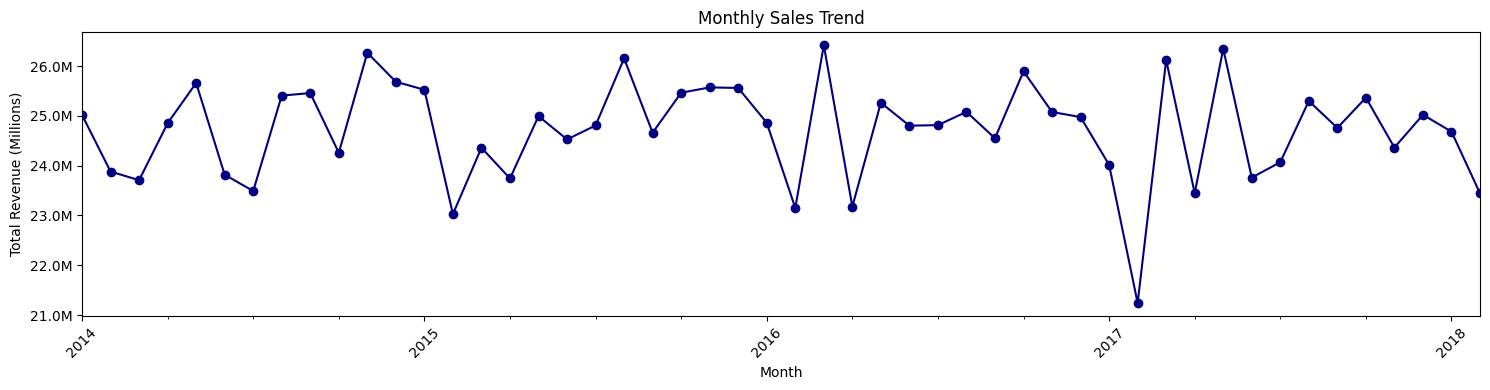

In [ ]:
# Convert order_date to monthly period (e.g., 2022-01, 2022-02)
df['order_month'] = df['order_date'].dt.to_period('M')

# Calculate total revenue for each month
monthly_sales = df.groupby('order_month')['revenue'].sum()

# Set figure size for clarity
plt.figure(figsize=(15,4))

# Plot the monthly sales trend with circle markers and navy line
monthly_sales.plot(marker='o', color='navy')

# Scale y-axis values to millions for readability
from matplotlib.ticker import FuncFormatter
formatter = FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
plt.gca().yaxis.set_major_formatter(formatter)

# Add title and axis labels
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue (Millions)')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Adjust layout to prevent clipping
plt.tight_layout()
plt.show()


**INSIGHTS —**

Sales consistently show a clear seasonal rhythm:
- January opens strong at around 99M.
- A steady decline follows, reaching the year’s low near 95M in April.
- Momentum returns with rebounds in May and August, peaking near 102M.
- From September through December, sales stabilize into a plateau between 99M and 101M.
This recurring cycle highlights a post–New Year surge, a spring slowdown, and a mid–summer lift before leveling off at year’s end.

**2. Monthly Sales Trend (All Years Combined)**

Goal: Highlight overall seasonality patterns by aggregating sales across all years for each calendar month

Chart: Line chart

EDA Type: Temporal (time series)

Structure: Line with markers, months ordered January to December based on month number

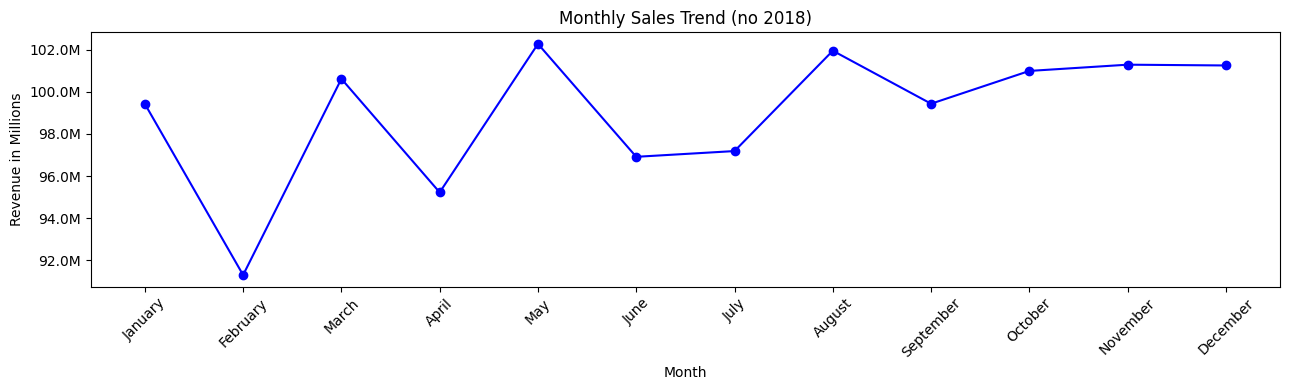

In [ ]:
# Step 1: remove 2018 data and make a copy so we can safely add new columns
df2 = df[df['order_date'].dt.year != 2018].copy()

# Step 2: create month number and month name columns
df2['order_month_num'] = df2['order_date'].dt.month
df2['order_month_name'] = df2['order_date'].dt.strftime('%B')

# Step 3: group by month and add up revenue
monthly_sales = df2.groupby(['order_month_num', 'order_month_name'])['revenue'].sum()

# Step 4: sort by month number so months are in order
monthly_sales = monthly_sales.sort_index()

# Step 5: make the plot
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(13,4))
plt.plot(
    monthly_sales.index.get_level_values(1),  # month names
    monthly_sales.values,                     # revenue values
    marker='o',
    color='blue'
)

# Step 6: format y-axis to show millions
def millions(x, pos):
    return str(round(x/1000000,1)) + "M"
plt.gca().yaxis.set_major_formatter(FuncFormatter(millions))

# Step 7: add labels and title
plt.title("Monthly Sales Trend (no 2018)")
plt.xlabel("Month")
plt.ylabel("Revenue in Millions")

# Step 8: rotate month names so they don’t overlap
plt.xticks(rotation=45)

# Step 9: fix layout
plt.tight_layout()

# Step 10: show the chart
plt.show()

**INSIGHTS -**

- January consistently opens strong, with revenue around 95M, reflecting a post–New Year surge.
- Spring performance weakens, with sales dipping through February and April.
- Recovery is evident in May and August, where revenue peaks near 99–101M.
- September through December remain stable, showing a plateau in the 99–101M range.
- The recurring pattern highlights a seasonal cycle: early‑year strength, spring slowdown, mid‑summer lift, and steady year‑end performance.


**3. Top 10 Products by Revenue (Millions)**

- Objective: Highlight the highest‑earning products to guide marketing priorities and inventory planning.
- Visualization: Horizontal bar chart for clear comparison.
- Analysis Type: Univariate (single variable focus on revenue).
- Structure: Bars arranged in descending order, revenue scaled in millions, showing the top 10 products.


/tmp/ipython-input-3621726301.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


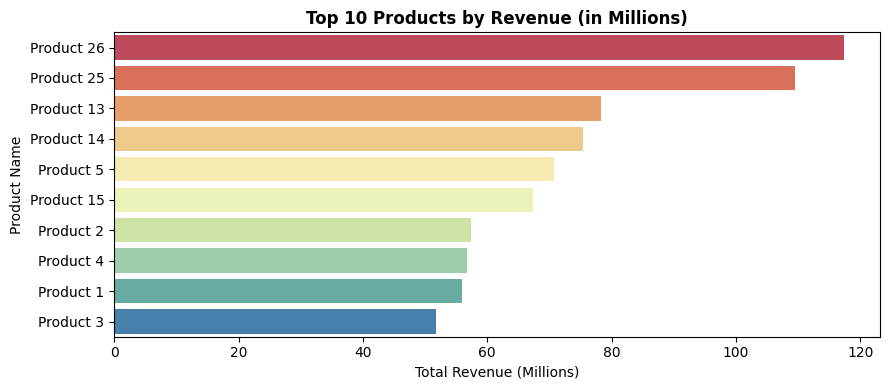

In [ ]:
# Step 1: calculate total revenue per product (in millions)
top_products = df.groupby('product_name')['revenue'].sum() / 1_000_000

# Step 2: select the top 10 products
top_products = top_products.nlargest(10)

# Step 3: set up the figure
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 4))

# Step 4: plot horizontal bar chart with a refined palette
sns.barplot(
    x=top_products.values,   # revenue values in millions
    y=top_products.index,    # product names
    palette='Spectral'       # aesthetically pleasing palette
)

# Step 5: add title and labels
plt.title("Top 10 Products by Revenue (in Millions)", fontsize=12, weight='bold')
plt.xlabel("Total Revenue (Millions)")
plt.ylabel("Product Name")

# Step 6: adjust layout
plt.tight_layout()

# Step 7: show chart
plt.show()

**Product Performance Insights**

- Products 26 and 25 lead significantly, generating 118M and 110M respectively.
- A sharp drop follows with Product 13 at 78M, while the mid‑tier cluster holds steady between 68M and 75M.
- The bottom four products group tightly in the 52–57M range, reflecting similar performance constraints.
- Strategic focus should be on growth pilots for mid‑tier products and efficiency improvements for lower performers to drive meaningful overall gains.


**4. Top 10 Products by Average Profit Margin**

- Objective: Compare product profitability to identify high‑margin items for strategic focus.
- Visualization: Horizontal bar chart for clear comparison.
- Analysis Type: Univariate (single variable: average profit margin).
- Structure: Bars sorted in descending order, displaying the top 10 products by average profit margin values.



/tmp/ipython-input-590255324.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


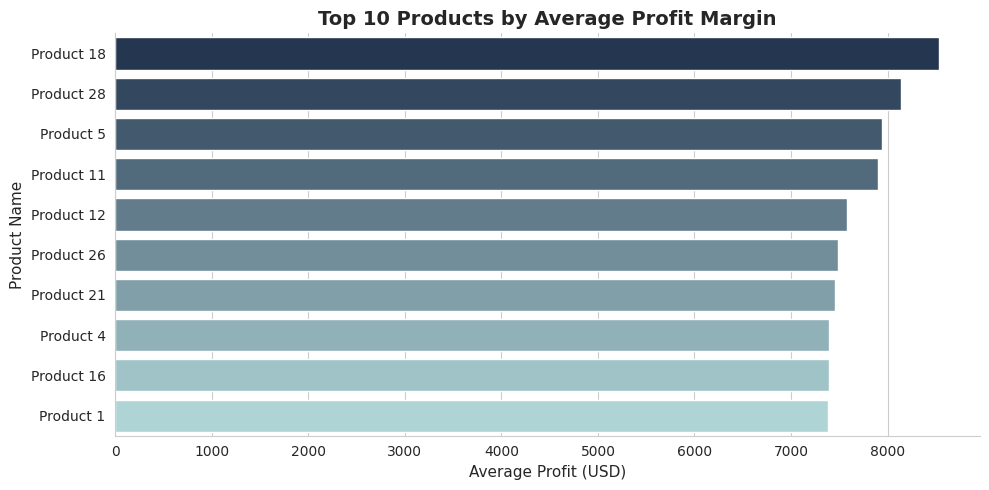

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1️⃣ Compute average profit per product and take the top 10
top_margin = (
    df.groupby('product_name')['profit']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

# 2️⃣ Create a high-quality professional palette (Tableau-inspired blue gradient)
custom_palette = sns.color_palette("blend:#1D3557,#A8DADC", n_colors=10)

# 3️⃣ Set clean white theme
sns.set_style("whitegrid")

# 4️⃣ Set figure size
plt.figure(figsize=(10, 5))

# 5️⃣ Plot horizontal bar chart
sns.barplot(
    x=top_margin.values,
    y=top_margin.index,
    palette=custom_palette
)

# 6️⃣ Add titles and labels (clean formatting)
plt.title("Top 10 Products by Average Profit Margin", fontsize=14, weight='bold')
plt.xlabel("Average Profit (USD)", fontsize=11)
plt.ylabel("Product Name", fontsize=11)

# 7️⃣ Remove top/right spines for modern look
sns.despine()

# 8️⃣ Tight layout
plt.tight_layout()
plt.show()

**Key Insights**

Products 18 and 28 demonstrate the strongest performance, achieving average profit margins in the range of $8.0K–$8.3K.

They are closely followed by Products 5 and 11, with margins between $7.9K–$8.0K, indicating consistent high-margin contribution within the top tier.

Mid-tier performers — including Products 12, 26, and 21 — cluster within the $7.7K–$7.8K range, reflecting stable but comparatively moderate profitability.

The lowest-performing group (Products 4, 16, and 1) records margins between $7.4K–$7.6K, signaling potential margin optimization opportunities.

**5. Sales by Channel (Pie Chart)**

- Objective: Present the distribution of total sales across channels to highlight dominant routes.
- Visualization: Pie chart with clear percentage labels for readability.
- Analysis Type: Univariate (single variable: sales by channel).
- Structure: Segments differentiated by color, with adjusted start angle for balanced presentation.


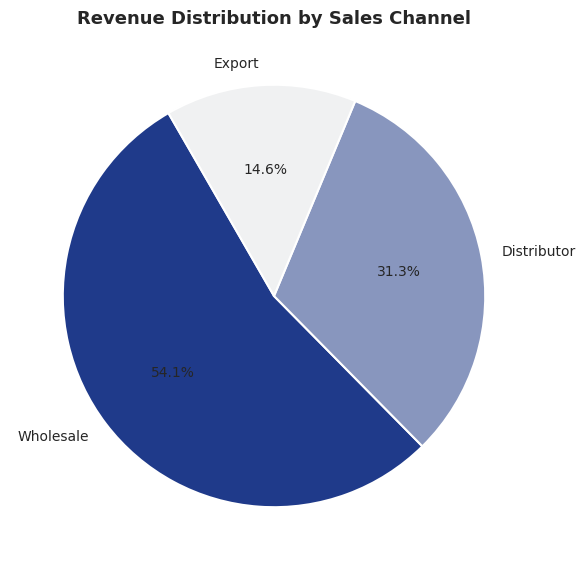

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1️⃣ Aggregate total revenue by channel (descending order)
chan_sales = (
    df.groupby('channel')['revenue']
      .sum()
      .sort_values(ascending=False)
)

# 2️⃣ Create a single-color gradient palette (dark → light blue)
base_color = "#1F3A8A"  # Deep corporate blue
custom_palette = sns.light_palette(base_color,
                                    n_colors=len(chan_sales),
                                    reverse=True)

# 3️⃣ Set clean theme
sns.set_style("white")

# 4️⃣ Set figure size
plt.figure(figsize=(6, 6))

# 5️⃣ Plot pie chart with gradient shades
plt.pie(
    chan_sales.values,
    labels=chan_sales.index,
    autopct='%1.1f%%',
    startangle=120,
    colors=custom_palette,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
    textprops={'fontsize': 10}
)

# 6️⃣ Add professional title
plt.title("Revenue Distribution by Sales Channel",
          fontsize=13,
          weight='bold')

plt.tight_layout()
plt.show()

**Sales Channel Insights**

- Wholesale dominates, accounting for 54% of total sales.
- Distributors contribute ~31%, while exports represent ~15%, underscoring reliance on domestic bulk channels.
- The current mix highlights a concentration risk, with heavy dependence on wholesale.
- To strengthen resilience, prioritize expanding export initiatives through targeted international marketing and strategic partnerships.


**6. Average Order Value (AOV) Distribution**

- Objective: Assess the spread of order values to identify typical spending levels and detect outliers.
- Visualization: Histogram for frequency distribution.
- Analysis Type: Univariate (single variable: order value).
- Structure: 50 bins with colored bars and edge highlights to clearly show the distribution pattern.


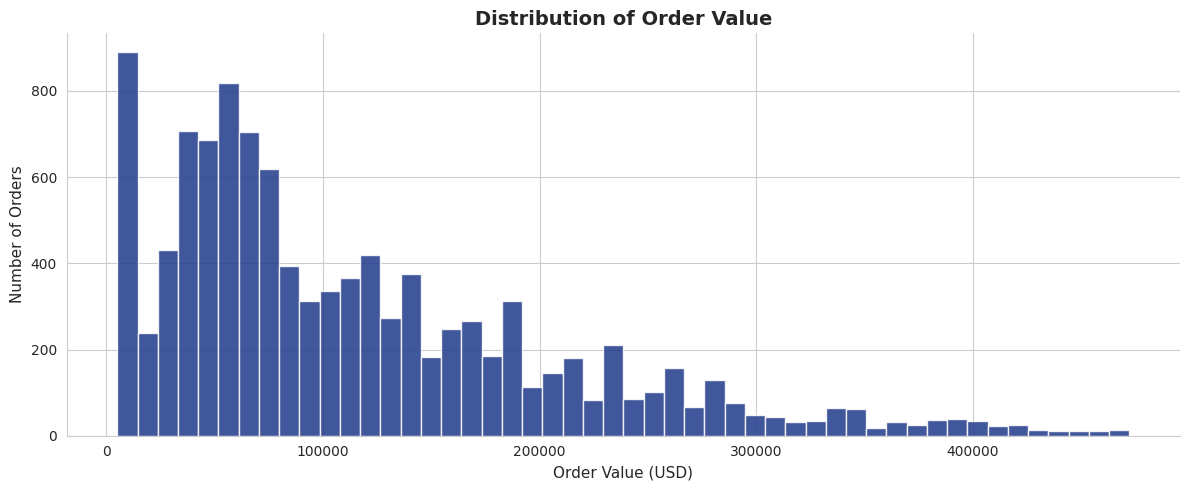

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1️⃣ Calculate total revenue per order (Order Value)
aov = df.groupby('order_number')['revenue'].sum()

# 2️⃣ Set clean professional theme
sns.set_style("whitegrid")

# 3️⃣ Set figure size
plt.figure(figsize=(12, 5))

# 4️⃣ Plot histogram with professional styling
plt.hist(
    aov,
    bins=50,
    color="#1F3A8A",     # Deep corporate blue
    edgecolor="white",   # Clean separation between bars
    alpha=0.85           # Slight transparency for polish
)

# 5️⃣ Add title and labels with hierarchy
plt.title("Distribution of Order Value", fontsize=14, weight='bold')
plt.xlabel("Order Value (USD)", fontsize=11)
plt.ylabel("Number of Orders", fontsize=11)

# 6️⃣ Remove unnecessary spines
sns.despine()

plt.tight_layout()
plt.show()

**Order Value Distribution Insights**

- The distribution is right‑skewed, with most orders between 20K and 120K.
- A clear peak occurs around 50K–60K, marking typical spending levels.
- A long tail of high‑value orders extends up to 400K–500K, though these represent only a small share.


**7. Profit Margin % vs. Unit Price**

- Objective: Assess the relationship between unit price and profit margin percentage across orders.
- Visualization: Scatter plot to reveal patterns and correlations.
- Analysis Type: Bivariate (two variables: unit price and profit margin %).
- Structure: Scatter points plotted with transparency to highlight data density and reduce overlap.


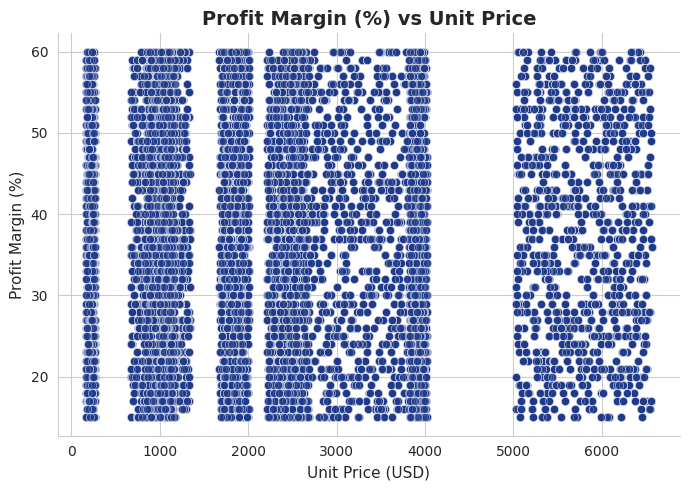

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1️⃣ Calculate profit margin percentage
df['profit_margin_pct'] = (df['profit'] / df['revenue']) * 100

# 2️⃣ Set clean professional theme
sns.set_style("whitegrid")

# 3️⃣ Set figure size
plt.figure(figsize=(7, 5))

# 4️⃣ Plot scatter with refined styling
plt.scatter(
    df['unit_price'],
    df['profit_margin_pct'],
    color="#1F3A8A",     # Deep corporate blue
    alpha=0.6,           # Transparency for overlap handling
    edgecolor="white",   # Clean marker borders
    linewidth=0.5
)

# 5️⃣ Add professional title and labels
plt.title("Profit Margin (%) vs Unit Price", fontsize=14, weight='bold')
plt.xlabel("Unit Price (USD)", fontsize=11)
plt.ylabel("Profit Margin (%)", fontsize=11)

# 6️⃣ Remove unnecessary spines
sns.despine()

plt.tight_layout()
plt.show()

**Profit Margin vs. Unit Price Insights**

- Margins cluster between ~18% and 60%, with no clear link to unit price (ranging from ~6,500 upward).
- Horizontal bands highlight consistent margin tiers across the price spectrum, reflecting uniform pricing practices.
- Outliers below 18% at both ends of the price range may point to cost inefficiencies or pricing issues needing review.


**8. Unit Price Distribution per Product**

- Objective: Compare pricing variability across products to assess consistency and detect outliers.
- Visualization: Boxplot for clear view of spread and anomalies.
- Analysis Type: Bivariate (unit price across product categories).
- Structure: Boxplots with rotated product labels to display unit price ranges and highlight variability.




/tmp/ipython-input-197822508.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


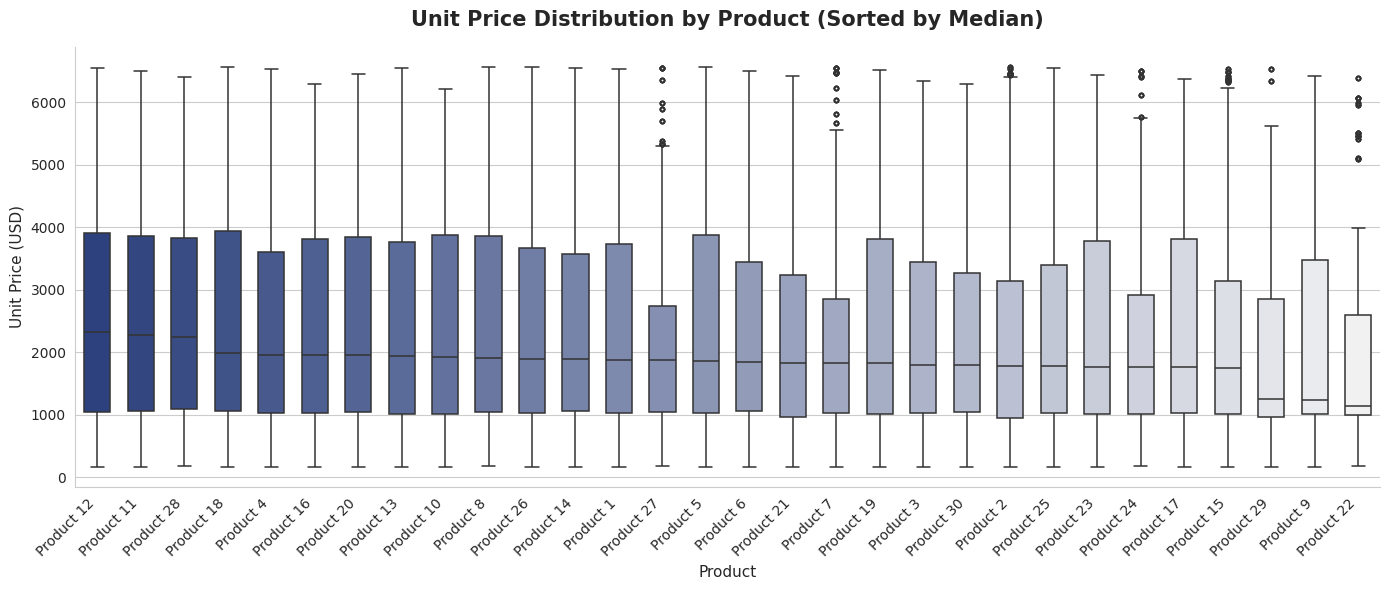

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1️⃣ Professional theme
sns.set_style("whitegrid")

# 2️⃣ Sort products by median unit price (improves interpretability)
order = (
    df.groupby('product_name')['unit_price']
      .median()
      .sort_values(ascending=False)
      .index
)

# 3️⃣ Create single-tone gradient palette
base_color = "#1F3A8A"
palette = sns.light_palette(
    base_color,
    n_colors=len(order),
    reverse=True
)

# 4️⃣ Set figure size
plt.figure(figsize=(14, 6))

# 5️⃣ Create boxplot
sns.boxplot(
    data=df,
    x='product_name',
    y='unit_price',
    order=order,
    palette=palette,
    width=0.6,
    fliersize=3,
    linewidth=1.1
)

# 6️⃣ Improve title hierarchy
plt.title("Unit Price Distribution by Product (Sorted by Median)",
          fontsize=15,
          weight='bold',
          pad=15)

plt.xlabel("Product", fontsize=11)
plt.ylabel("Unit Price (USD)", fontsize=11)

# 7️⃣ Improve tick readability
plt.xticks(rotation=45, ha='right')

# 8️⃣ Remove extra spines
sns.despine()

plt.tight_layout()
plt.show()


**Unit Price Distribution Insights**

- Products 8, 17, 27, 20, and 28 show high‑end revenue spikes well above their upper whiskers, likely driven by bulk orders, special editions, or premium bundles.
- Deep low‑end outliers near 100 for Products 20 and 27 suggest promotional giveaways or test SKUs that depress average prices.
- For accurate margin and pricing analysis, exclude these outlier transactions from averages.
- Then evaluate whether such anomalies should be formalized as ongoing promotions or phased out to stabilize pricing performance.


**9. Total Sales by U.S. Region**

- Objective: Benchmark regional sales performance to identify leading markets and areas requiring targeted growth initiatives.
- Visualization: Horizontal bar chart for clear comparative analysis.
- Analysis Type: Univariate comparison (sales totals by region).
- Structure: Bars sorted in ascending order (Northeast → West) to provide a bottom‑to‑top ranking, with the X‑axis in millions USD and the Y‑axis listing regions.


/tmp/ipython-input-1491085884.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


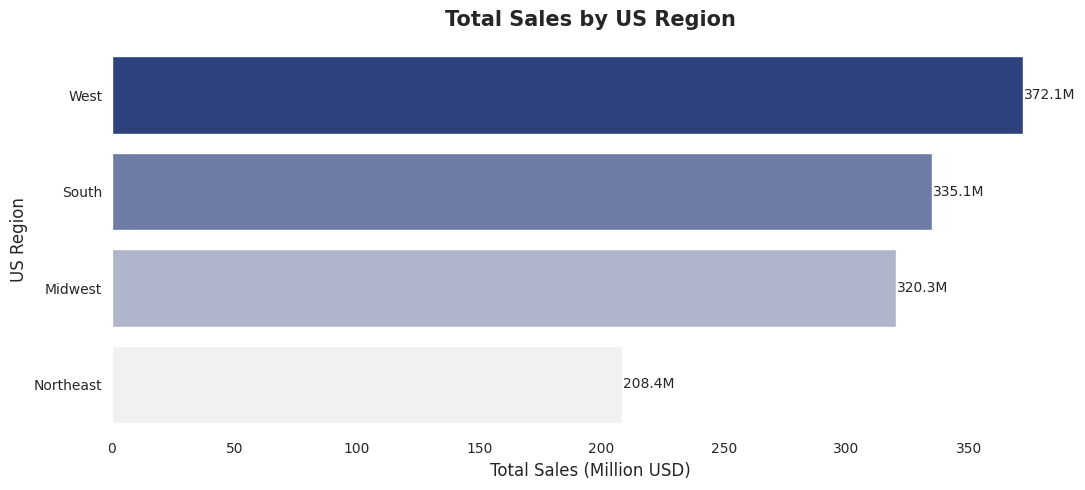

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1️⃣ Aggregate total sales by region (in millions, sorted)
region_sales = (
    df.groupby('us_region')['revenue']
      .sum()
      .sort_values(ascending=False)
      / 1e6
)

# 2️⃣ Professional theme
sns.set_style("white")

# 3️⃣ Create single-tone gradient (dark = highest sales)
base_color = "#1F3A8A"  # Corporate deep blue
palette = sns.light_palette(
    base_color,
    n_colors=len(region_sales),
    reverse=True
)

# 4️⃣ Plot
plt.figure(figsize=(11, 5))
ax = sns.barplot(
    x=region_sales.values,
    y=region_sales.index,
    palette=palette
)

# 5️⃣ Add value labels at end of bars
for i, v in enumerate(region_sales.values):
    ax.text(v + 0.2, i, f"{v:,.1f}M",
            va='center',
            fontsize=10)

# 6️⃣ Title & labels (clean hierarchy)
plt.title("Total Sales by US Region",
          fontsize=15,
          weight='bold',
          pad=15)

plt.xlabel("Total Sales (Million USD)", fontsize=12)
plt.ylabel("US Region", fontsize=12)

# 7️⃣ Remove extra spines for cleaner look
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

**Regional and State Sales Insights**

- West leads (~$360M, 35%), with South and Midwest close behind (~$320M each, 32%).
- Northeast lags (~$210M, 20%), signaling growth potential through targeted investment.
- California dominates (~$230M, 7,500 orders), while Illinois, Florida, and Texas form a strong second tier ($85–110M).
- Revenue and order counts align, suggesting consistent average order values; growth depends on boosting mid‑tier volumes and raising order size in lower‑performing states.




# **10 Total Sales by State (Choropleth Map)**

- Objective: Visualize geographic sales distribution to highlight high‑ and low‑performing states and uncover regional gaps.
- Visualization: U.S. choropleth map for clear spatial context.
- Analysis Type: Univariate geospatial (sales totals by state).
- Structure: States shaded by total sales (millions USD) using a blue gradient, with a right‑side legend showing scale. Hover tooltips display exact sales values for each state.


In [ ]:
import plotly.express as px

# 1️⃣ Aggregate revenue by state (convert to millions)
state_sales = (
    df.groupby('state')['revenue']
      .sum()
      .reset_index()
)

state_sales['revenue_m'] = state_sales['revenue'] / 1e6

# 2️⃣ Create corporate blue monochrome scale (dark = higher sales)
custom_scale = [
    [0.0, "#E6ECF5"],   # very light blue
    [0.3, "#9DB7E0"],
    [0.6, "#4A77C9"],
    [1.0, "#1F3A8A"]    # deep corporate blue
]

# 3️⃣ Choropleth
fig = px.choropleth(
    state_sales,
    locations='state',
    locationmode='USA-states',
    color='revenue_m',
    scope='usa',
    labels={'revenue_m': 'Total Sales (Million USD)'},
    color_continuous_scale=custom_scale,
    hover_data={
        'state': True,
        'revenue_m': ':.2f'
    }
)

# 4️⃣ Layout refinement
fig.update_layout(
    title={
        'text': "Total Sales by State (USD Millions)",
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 18}
    },
    margin=dict(l=10, r=10, t=60, b=10),
    coloraxis_colorbar=dict(
        title="Sales (M USD)",
        ticksuffix="M",
        len=0.75
    )
)

# 5️⃣ Improve map aesthetics
fig.update_geos(
    bgcolor='rgba(0,0,0,0)',
    lakecolor='white',
    showlakes=False
)

fig.show()

**State Sales Insights**

- California leads ($230M), with Illinois ($112M) and Florida ($90M) forming the top‑tier markets.
- Mid‑tier states such as Texas ($85M) and New York ($55M) show steady performance but remain well behind the leaders.
- Lower‑tier states (New Jersey $47M to Massachusetts $35M) reflect uneven market penetration.
- Strategic focus: Strengthen top‑tier states with tailored promotions and drive growth in under‑penetrated regions to close performance gaps.


# **11. Top 10 States by Revenue and Order Volume**

- Objective: Highlight the highest revenue‑generating states and compare their order volumes.
- Visualization: Two bar charts for side‑by‑side comparison.
- Analysis Type: Multivariate (revenue vs. order count).
- Structure:
- Chart 1: Top 10 states ranked by revenue (in millions USD).
- Chart 2: Top 10 states ranked by number of orders.


/tmp/ipython-input-3580137885.py:35: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipython-input-3580137885.py:57: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




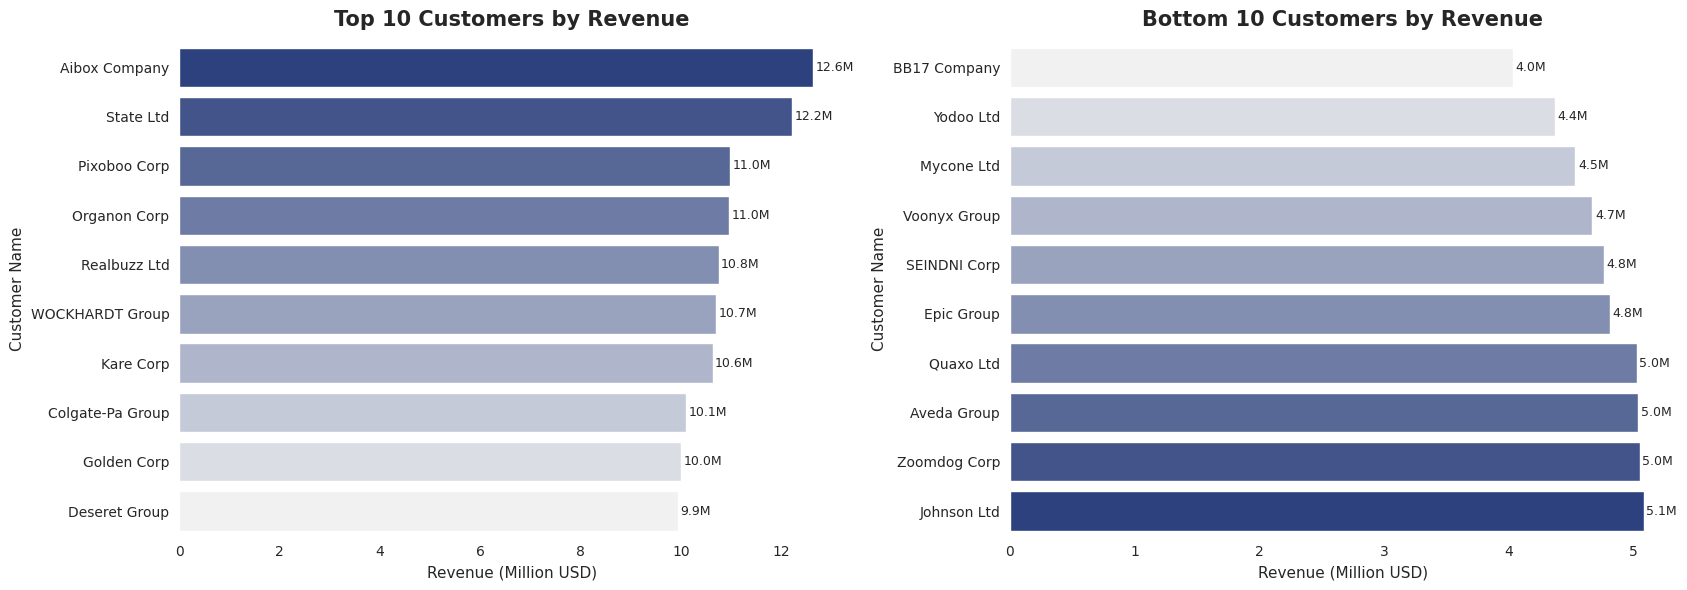

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1️⃣ Aggregate revenue (Top & Bottom 10)
top_rev = (
    df.groupby('customer_name')['revenue']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

bottom_rev = (
    df.groupby('customer_name')['revenue']
      .sum()
      .sort_values(ascending=True)
      .head(10)
)

# Convert to millions
top_rev_m = top_rev / 1e6
bottom_rev_m = bottom_rev / 1e6

# 2️⃣ Professional theme
sns.set_style("white")

# 3️⃣ Create single corporate gradient
base_color = "#1F3A8A"
top_palette = sns.light_palette(base_color, n_colors=len(top_rev_m), reverse=True)
bottom_palette = sns.light_palette(base_color, n_colors=len(bottom_rev_m))

# 4️⃣ Create subplots
fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# ------------------ TOP 10 ------------------
ax1 = sns.barplot(
    x=top_rev_m.values,
    y=top_rev_m.index,
    palette=top_palette,
    ax=axes[0]
)

axes[0].set_title("Top 10 Customers by Revenue",
                  fontsize=15,
                  weight='bold',
                  pad=12)

axes[0].set_xlabel("Revenue (Million USD)", fontsize=11)
axes[0].set_ylabel("Customer Name", fontsize=11)

# Add value labels
for i, v in enumerate(top_rev_m.values):
    ax1.text(v + 0.05, i, f"{v:,.1f}M",
             va='center',
             fontsize=9)

# ------------------ BOTTOM 10 ------------------
ax2 = sns.barplot(
    x=bottom_rev_m.values,
    y=bottom_rev_m.index,
    palette=bottom_palette,
    ax=axes[1]
)

axes[1].set_title("Bottom 10 Customers by Revenue",
                  fontsize=15,
                  weight='bold',
                  pad=12)

axes[1].set_xlabel("Revenue (Million USD)", fontsize=11)
axes[1].set_ylabel("Customer Name", fontsize=11)

# Add value labels
for i, v in enumerate(bottom_rev_m.values):
    ax2.text(v + 0.02, i, f"{v:,.1f}M",
             va='center',
             fontsize=9)

# 5️⃣ Clean look
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

# **Customer Revenue Insights**
- Top tier: Aibox Company ($12.5M) and State Ltd ($12.2M) lead, with Deseret Group ($9.9M) rounding out a tightly clustered 10–12M segment.
- Lower tier: Johnson Ltd ($5.1M) down to BB17 Company ($4.1M) generate roughly half the revenue of top customers.
- The sharp drop from ~10M+ to 4–5M underscores high revenue concentration among the top accounts.
- Strategic focus: Prioritize retention and upsell within the top ten, while driving targeted growth initiatives to elevate lower‑revenue customers.


#**12. Average Profit Margin by Channel**

- Objective: Benchmark average profit margins across sales channels to identify the most and least profitable routes.
- Visualization: Vertical bar chart with labeled margin percentages.
- Analysis Type: Bivariate (channel vs. margin %).
- Structure: Bars sorted in descending order by channel to highlight profitability tiers.


/tmp/ipython-input-236427725.py:26: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




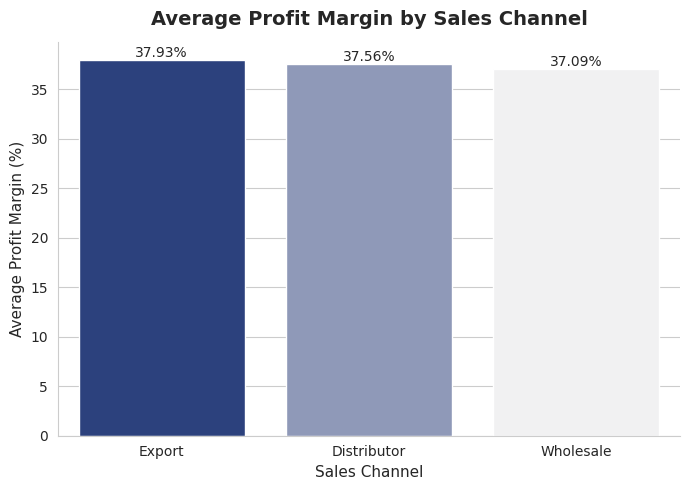

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Aggregate average profit margin by sales channel
channel_margin = (
    df.groupby('channel')['profit_margin_pct']
      .mean()
      .sort_values(ascending=False)
)

# Set professional theme
sns.set_style("whitegrid")

# Create a single-color gradient palette (dark = higher margin)
base_color = "#1F3A8A"
palette = sns.light_palette(
    base_color,
    n_colors=len(channel_margin),
    reverse=True
)

# Create figure
plt.figure(figsize=(7, 5))

# Plot bar chart
ax = sns.barplot(
    x=channel_margin.index,
    y=channel_margin.values,
    palette=palette
)

# Add title and labels
plt.title("Average Profit Margin by Sales Channel",
          fontsize=14,
          weight="bold",
          pad=12)

plt.xlabel("Sales Channel", fontsize=11)
plt.ylabel("Average Profit Margin (%)", fontsize=11)

# Add percentage labels above bars
for i, value in enumerate(channel_margin.values):
    ax.text(
        i,
        value + 0.3,
        f"{value:.2f}%",
        ha="center",
        fontsize=10
    )

# Clean up spines
sns.despine()

plt.tight_layout()
plt.show()

#**Channel Profitability Insights**

- Export leads with a 37.93% margin, closely followed by Distributor (37.56%) and Wholesale (37.09%).
- The narrow spread (<0.2%) reflects consistently strong profitability across all channels.
- This uniformity signals well‑controlled costs and effective pricing discipline.
- Strategic focus: Drive volume growth in Export while sustaining efficiency in Distributor and Wholesale to maximize returns.


#**13. Top and Bottom 10 Customers by Revenue**
- Objective: Identify highest‑ and lowest‑revenue customers to tailor engagement strategies.
- Visualization: Side‑by‑side horizontal bar charts.
- Analysis Type: Multivariate (customer vs. revenue).
- Structure: Left chart ranks top 10 customers by revenue (M USD); right chart ranks bottom 10 customers.


/tmp/ipython-input-3781089378.py:29: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




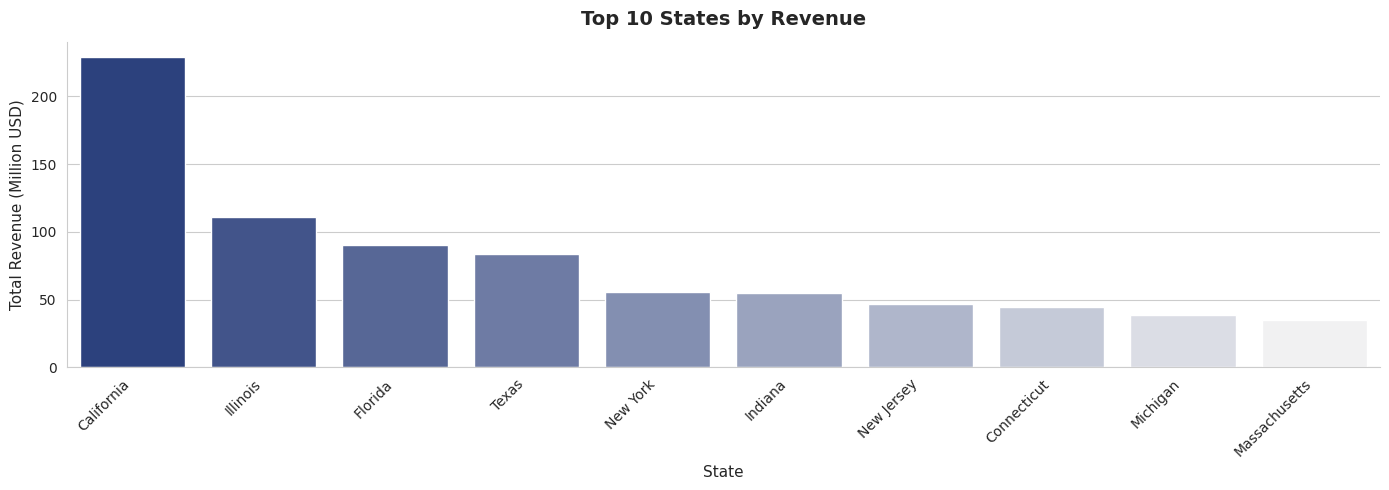

/tmp/ipython-input-3781089378.py:48: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




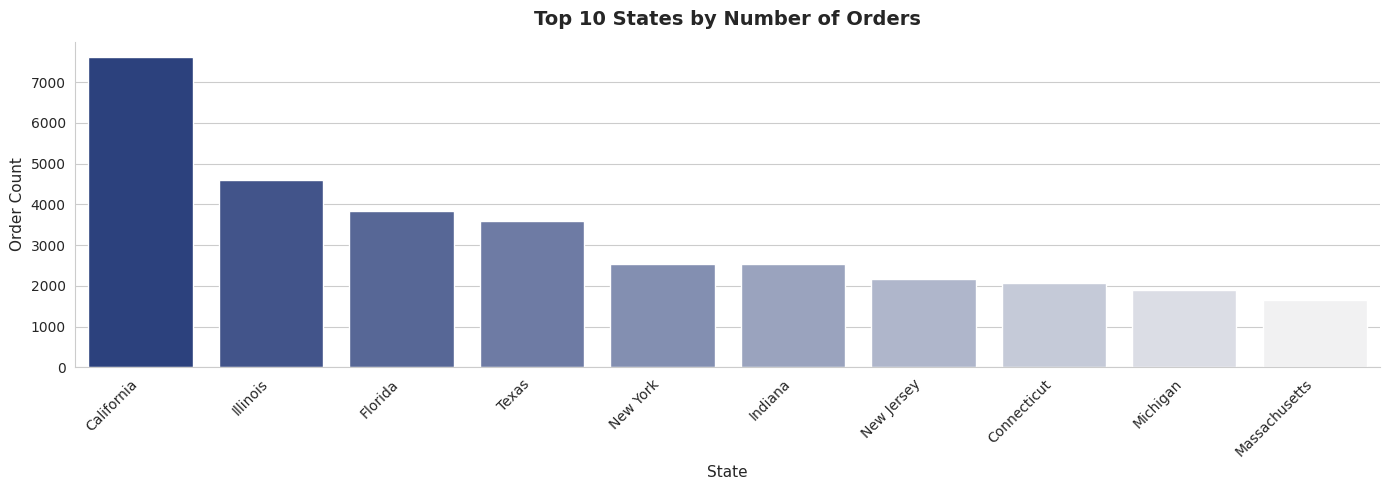

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Aggregate total revenue and unique order count per state
state_rev = (
    df.groupby('state_name')
      .agg(
          revenue=('revenue', 'sum'),
          orders=('order_number', 'nunique')
      )
      .sort_values('revenue', ascending=False)
      .head(10)
)

# Set consistent visual theme
sns.set_style("whitegrid")

# Create single-tone gradient palette
base_color = "#1F3A8A"
palette = sns.light_palette(
    base_color,
    n_colors=len(state_rev),
    reverse=True
)

# ---------------- Revenue Plot ----------------
plt.figure(figsize=(14, 5))

sns.barplot(
    x=state_rev.index,
    y=state_rev['revenue'] / 1e6,
    palette=palette
)

plt.title("Top 10 States by Revenue", fontsize=14, weight="bold", pad=12)
plt.xlabel("State", fontsize=11)
plt.ylabel("Total Revenue (Million USD)", fontsize=11)

plt.xticks(rotation=45, ha='right')
sns.despine()

plt.tight_layout()
plt.show()

# ---------------- Orders Plot ----------------
plt.figure(figsize=(14, 5))

sns.barplot(
    x=state_rev.index,
    y=state_rev['orders'],
    palette=palette
)

plt.title("Top 10 States by Number of Orders", fontsize=14, weight="bold", pad=12)
plt.xlabel("State", fontsize=11)
plt.ylabel("Order Count", fontsize=11)

plt.xticks(rotation=45, ha='right')
sns.despine()

plt.tight_layout()
plt.show()

#**Key Insights**

California is the clear market leader, driving the highest revenue and order volume by a wide margin.

Illinois, Florida, and Texas represent the second performance tier, contributing strong but comparatively lower volumes.

Revenue rankings closely align with order volumes, indicating that sales performance is largely driven by transaction volume rather than pricing differences.

Mid- and lower-tier states present scalable growth opportunities through improved market penetration and targeted expansion strategies.

# Customer Segmentation: Revenue vs. Profit Margin

- Objective: Segment customers by total revenue and average profit margin, incorporating order volume.
- Visualization: Bubble chart (scatter plot with variable point sizes).
- Analysis Type: Multivariate (revenue vs. margin, sized by orders).
- Structure: Scatter points sized by number of orders, plotted against revenue and margin to highlight customer segments.


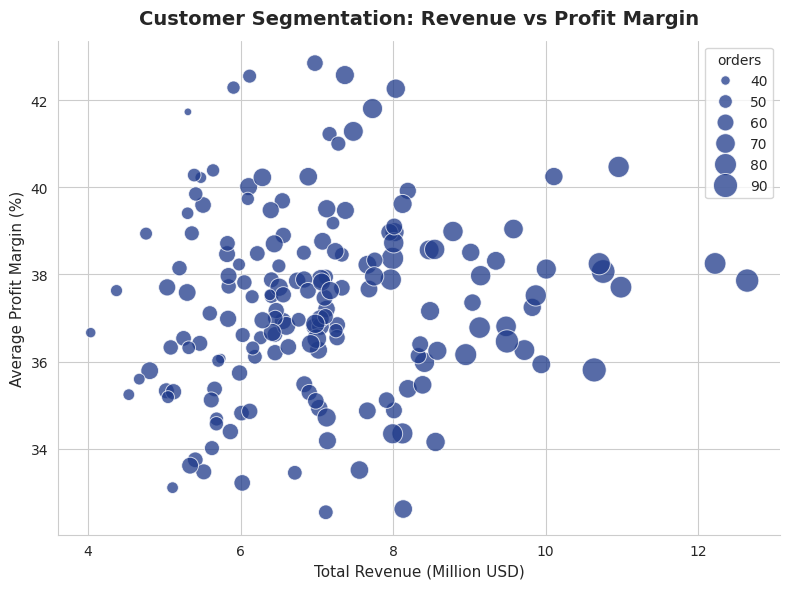

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Aggregate metrics per customer
cust_summary = (
    df.groupby('customer_name')
      .agg(
          total_revenue=('revenue', 'sum'),
          total_profit=('profit', 'sum'),
          avg_margin=('profit_margin_pct', 'mean'),
          orders=('order_number', 'nunique')
      )
)

# Convert revenue to millions
cust_summary['total_revenue_m'] = cust_summary['total_revenue'] / 1e6

# Set professional theme
sns.set_style("whitegrid")

plt.figure(figsize=(8, 6))

# Bubble chart
sns.scatterplot(
    data=cust_summary,
    x='total_revenue_m',
    y='avg_margin',
    size='orders',
    sizes=(30, 300),
    alpha=0.75,
    color="#1F3A8A",
    edgecolor="white",
    linewidth=0.7
)

plt.title(
    "Customer Segmentation: Revenue vs Profit Margin",
    fontsize=14,
    weight="bold",
    pad=12
)

plt.xlabel("Total Revenue (Million USD)", fontsize=11)
plt.ylabel("Average Profit Margin (%)", fontsize=11)

sns.despine()
plt.tight_layout()
plt.show()

#**Customer Segmentation Insights**
- Large accounts (>$10M) keep margins steady at 36–40%, showing scale doesn’t erode profitability.
- Mid‑tier ($6–10M) customers hold stable margins (~34–40%), reflecting consistent pricing.
- Smaller accounts (<$6M) show volatile margins (33–43%), driven by costs or discounts.
- Revenue drives performance more than order volume, as margins remain steady regardless of order count.




#**15. Correlation Heatmap of Numeric Features**
- Objective: Assess relationships among key numeric variables to detect potential multicollinearity.
- Visualization: Annotated correlation heatmap with coefficient values.
- Analysis Type: Multivariate (numeric feature correlations).
- Structure: Heatmap displaying selected numeric columns, shaded by correlation strength, with annotations for clarity.


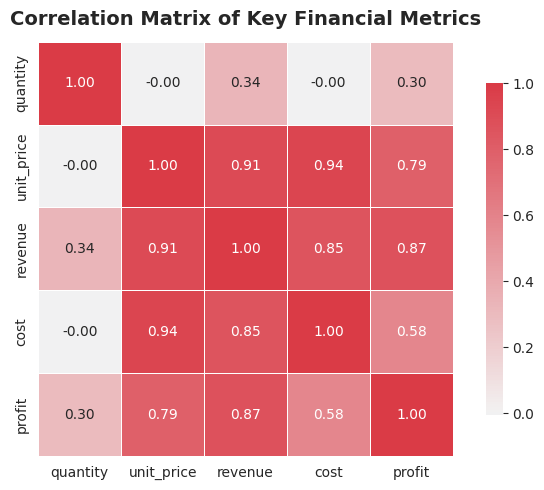

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numeric columns
num_cols = ['quantity', 'unit_price', 'revenue', 'cost', 'profit']

# Compute correlation matrix
corr = df[num_cols].corr()

# Set clean theme
sns.set_style("white")

plt.figure(figsize=(7, 5))

# Create a professional diverging palette (blue → white → dark blue tone)
cmap = sns.diverging_palette(240, 10, as_cmap=True)

# Plot heatmap
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap=cmap,
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix of Key Financial Metrics",
          fontsize=14,
          weight="bold",
          pad=12)

plt.tight_layout()
plt.show()

#**Correlation Insights**
- Profit and revenue rise together — strong link (0.87).
- Unit price drives everything: tightly tied to revenue, profit, and cost.
- Costs scale with revenue but margins vary, showing expense pressure doesn’t always cut profit.
- Quantity has little impact; pricing power matters more than volume.


In [ ]:
df

,order_number,order_date,customer_name,channel,product_name,quantity,unit_price,revenue,cost,state,...,us_region,lat,lon,budget,2017 budget,total_cost,profit,profit_maargin_pct,order_month,profit_margin_pct
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,...,South,32.08354,-81.09983,964940.231,<NA>,10946.058,4048.542,27.0,2014-01,27.0
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,1269.918,IN,...,Midwest,39.61366,-86.10665,2067108.120,<NA>,13969.098,11899.602,46.0,2014-01,46.0
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,684.740,CA,...,West,37.66243,-121.87468,5685138.270,<NA>,4108.440,1760.760,30.0,2014-01,30.0
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,Product 7,7,2338.3,16368.1,1028.852,IN,...,Midwest,39.16533,-86.52639,889737.555,<NA>,7201.964,9166.136,56.0,2014-01,56.0
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,1260.270,CT,...,Northeast,41.77524,-72.52443,1085037.329,<NA>,10082.160,8249.040,45.0,2014-01,45.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64099,SO - 0007573,2018-02-28,Dazzlesphe Corp,Wholesale,Product 26,12,1815.7,21788.4,980.478,PA,...,Northeast,40.15511,-74.82877,5685138.270,<NA>,11765.736,10022.664,46.0,2018-02,46.0
64100,SO - 0007706,2018-02-28,Yombu Corp,Export,Product 21,6,864.3,5185.8,579.081,IL,...,Midwest,42.11030,-88.03424,959899.218,<NA>,3474.486,1711.314,33.0,2018-02,33.0
64101,SO - 0007718,2018-02-28,Bath Group,Distributor,Product 13,11,3953.0,43483.0,2648.510,FL,...,South,26.24453,-80.20644,3720639.645,<NA>,29133.610,14349.390,33.0,2018-02,33.0
64102,SO - 0008084,2018-02-28,Linklinks Ltd,Distributor,Product 20,7,3959.7,27717.9,2930.178,NY,...,Northeast,42.91002,-78.74182,2067108.120,<NA>,20511.246,7206.654,26.0,2018-02,26.0


In [ ]:

# Export Final DataFrame to CSV
df.to_csv('Sales_data(EDA Exported).csv', index=False)

#**Key Insights**

- Monthly Revenue: Sales stayed steady at $23M–26.5M from 2014–2017, with no clear seasonal spikes. The only sharp dip (~$21.2M) came in early 2017, likely a one‑off issue.
- Channel Mix: Wholesale drives most sales (54%), followed by Distributors (31%) and Exports (15%) — leaving room to grow internationally.
- Top Products: Product 26 ($118M), Product 25 ($110M), and Product 13 ($78M) lead. Mid‑tier products bring in $68–75M, while the lowest performers sit at $52–57M.
- Profit Margins: Margins range widely (18%–60%) but don’t track closely with unit price, suggesting standardized pricing across tiers.
- Seasonal Volume: No strong monthly pattern, though sales tick up slightly in May–June. The early 2017 dip needs a closer look.
- Regional Performance: California dominates ($230M, 7,500+ orders). Illinois, Florida, and Texas follow ($85–110M, 3,500–4,500 orders). New York and Indiana sit mid‑pack (~$54M, 2,000 orders).


#**Recommendations**
- Outliers: Leave out bulk or promo orders when calculating averages.
- Margins: Use pricing tactics from top products on mid/low ones, and cut costs on weak sellers.
- Exports: Invest in overseas marketing and build distributor partnerships.
- Seasonality: Spend more during the January dip and May–June peak; check what caused the 2017 drop.
- Dashboards: Create summary tables for sales trends, channels, and products to use in Power BI.
